Anomaly Detection

In [4]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, roc_curve

# 시각화 스타일 설정
plt.style.use('seaborn-v0_8-whitegrid')

In [5]:
def generate_anomaly_data(n_samples=1000, contamination=0.05, random_state=512):
    """정상 데이터와 3가지 유형의 이상치 데이터를 생성합니다."""
    np.random.seed(random_state)
    
    # 정상 데이터 생성 (다변량 정규 분포)
    n_normal = int(n_samples * (1 - contamination))
    normal_data = np.random.multivariate_normal(mean=[0, 0], cov=[[1, 0], [0, 1]], size=n_normal)
    
    # 이상치 데이터 생성
    n_anomalies = n_samples - n_normal
    n_type1 = n_anomalies // 3
    n_type2 = n_anomalies // 3
    n_type3 = n_anomalies - n_type1 - n_type2
    
    # 1. 극단적 값을 가진 이상치
    extreme_anomalies = np.random.uniform(low=-6, high=6, size=(n_type1, 2))
    
    # 2. 군집에서 벗어난 이상치
    cluster_anomalies = np.random.multivariate_normal(mean=[4, 4], cov=[[0.1, 0], [0, 0.1]], size=n_type2)
    
    # 3. 무작위 이상치
    random_anomalies = np.random.uniform(low=-4, high=4, size=(n_type3, 2))
    
    # 데이터 결합 (0:정상, 1:이상치)
    X = np.vstack([normal_data, extreme_anomalies, cluster_anomalies, random_anomalies])
    y = np.array([0] * n_normal + [1] * n_anomalies)
    
    # 데이터 섞기
    idx = np.random.permutation(n_samples)
    X, y = X[idx], y[idx]
    
    return X, y

# 데이터 생성
X, y = generate_anomaly_data(n_samples=1000, contamination=0.05, random_state=42)

# 데이터 스케일링 (거리 기반 알고리즘인 LOF에 특히 중요)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"총 샘플 수: {len(X)}")
print(f"정상 샘플 수: {sum(y==0)}")
print(f"이상치 샘플 수: {sum(y==1)}")

총 샘플 수: 1000
정상 샘플 수: 950
이상치 샘플 수: 50


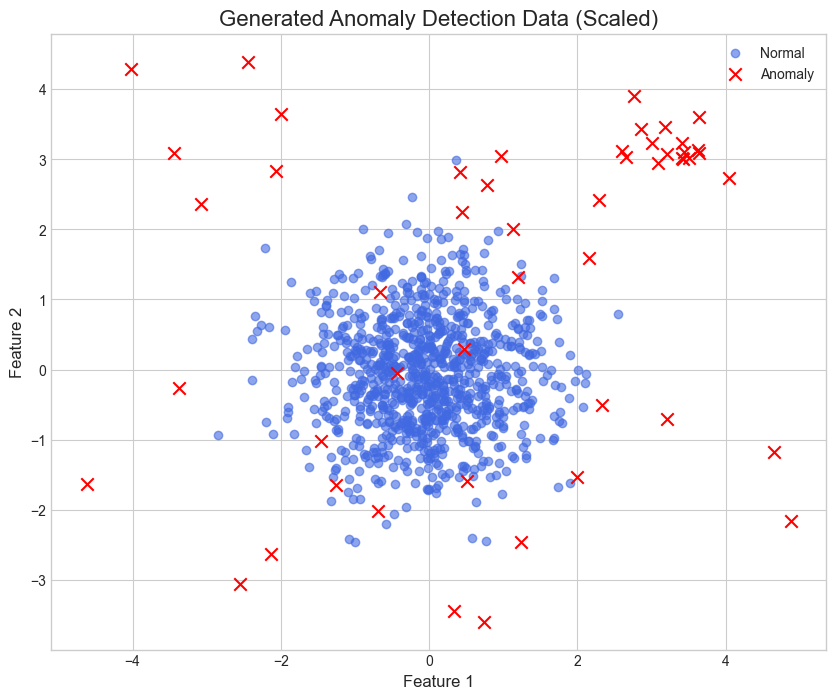

In [6]:
def plot_data(X, y, title):
    """데이터 분포를 시각화하는 함수"""
    plt.figure(figsize=(10, 8))
    plt.scatter(X[y==0, 0], X[y==0, 1], c='royalblue', alpha=0.6, label='Normal')
    plt.scatter(X[y==1, 0], X[y==1, 1], c='red', marker='x', s=80, label='Anomaly')
    plt.title(title, fontsize=16)
    plt.xlabel("Feature 1", fontsize=12)
    plt.ylabel("Feature 2", fontsize=12)
    plt.legend()
    plt.show()

plot_data(X_scaled, y, "Generated Anomaly Detection Data (Scaled)")

In [7]:
# 모델 정의
CONTAMINATION = 0.05
LOF_NEIGHBORS = 20

models = {
    "Local Outlier Factor": LocalOutlierFactor(n_neighbors=LOF_NEIGHBORS, contamination=CONTAMINATION, novelty=True),
    "Isolation Forest": IsolationForest(contamination=CONTAMINATION, random_state=512)
}

# 결과를 저장할 딕셔너리
results = {}

In [8]:
for name, model in models.items():
    print(f"--- {name} 모델 학습 및 평가 시작 ---")
    
    # 모델 학습
    model.fit(X_scaled)
    
    # 이상치 점수 계산 (점수가 높을수록 이상치일 확률이 높도록 부호를 변경)
    if name == "Local Outlier Factor":
        scores = -model.score_samples(X_scaled)
    else: # Isolation Forest
        scores = -model.score_samples(X_scaled)
        
    # 성능 평가
    auc_roc = roc_auc_score(y, scores)
    precision, recall, _ = precision_recall_curve(y, scores)
    auc_pr = auc(recall, precision)
    
    # 결과 저장
    results[name] = {'scores': scores, 'auc_roc': auc_roc, 'auc_pr': auc_pr, 'precision': precision, 'recall': recall}
    
    print(f"AUC-ROC: {auc_roc:.4f}")
    print(f"AUC-PR: {auc_pr:.4f}")
    print("\n")

--- Local Outlier Factor 모델 학습 및 평가 시작 ---
AUC-ROC: 0.9027
AUC-PR: 0.5483


--- Isolation Forest 모델 학습 및 평가 시작 ---
AUC-ROC: 0.9519
AUC-PR: 0.8497




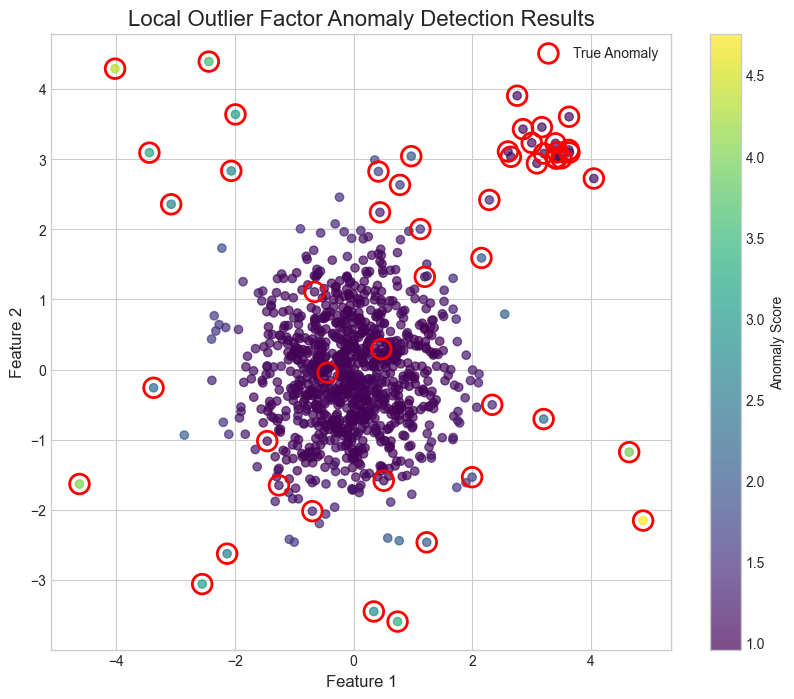

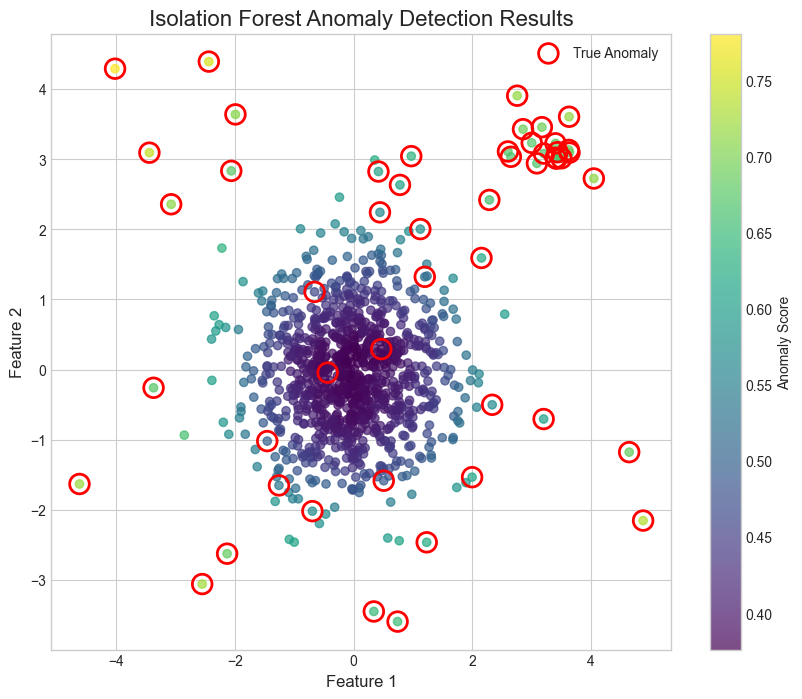

In [9]:
def plot_anomaly_scores(X, y, scores, title):
    """모델이 예측한 이상치 점수를 시각화하는 함수"""
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(X[:, 0], X[:, 1], c=scores, cmap='viridis', alpha=0.7)
    plt.colorbar(scatter, label='Anomaly Score')
    # 실제 이상치 위치 표시
    plt.scatter(X[y==1, 0], X[y==1, 1], facecolors='none', edgecolors='red', s=200, linewidths=2, label='True Anomaly')
    plt.title(title, fontsize=16)
    plt.xlabel("Feature 1", fontsize=12)
    plt.ylabel("Feature 2", fontsize=12)
    plt.legend()
    plt.show()

for name, result in results.items():
    plot_anomaly_scores(X_scaled, y, result['scores'], f"{name} Anomaly Detection Results")

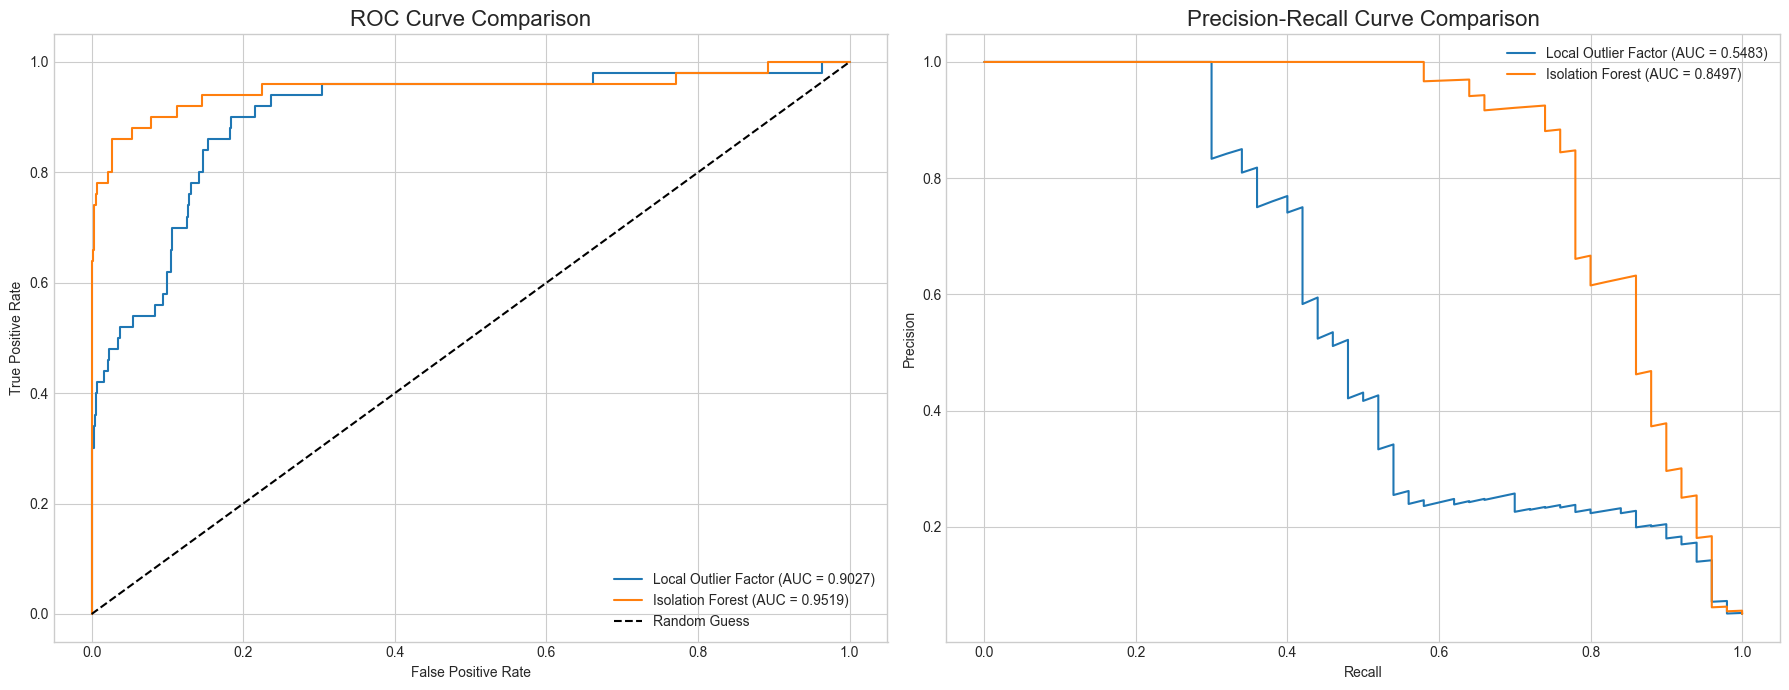

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ROC Curve
axes[0].set_title('ROC Curve Comparison', fontsize=16)
for name, result in results.items():
    fpr, tpr, _ = roc_curve(y, result['scores'])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC = {result['auc_roc']:.4f})")
axes[0].plot([0, 1], [0, 1], 'k--', label='Random Guess')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

# Precision-Recall Curve
axes[1].set_title('Precision-Recall Curve Comparison', fontsize=16)
for name, result in results.items():
    axes[1].plot(result['recall'], result['precision'], label=f"{name} (AUC = {result['auc_pr']:.4f})")
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()

plt.tight_layout()
plt.show()